# Đánh giá Độc lập Retrieval Stage & Grid Search Trọng số

Notebook này thực hiện đánh giá độc lập hiệu năng của tầng truy xuất tài liệu (Retrieval Stage) bằng các chỉ số Đánh giá Tìm kiếm Thông tin (Information Retrieval Metrics). Việc đánh giá offline này giúp:
1. **Tối ưu hóa chi phí và tốc độ**: Đo trực tiếp khả năng tìm kiếm mà không tốn tiền API hay thời gian đợi LLM sinh câu trả lời.
2. **Grid Search Trọng số**: Thử nghiệm và xác thực tỷ lệ kết hợp tối ưu giữa **BM25 (Sparse)** và **Dense (Vector)** Search.
3. **So sánh Chunker**: So sánh hiệu năng giữa `RecursiveCharacterTextSplitter` và `SemanticChunker`.

## Các chỉ số đo lường (IR Metrics):
- **Hit Rate@5**: Tỷ lệ tìm thấy ít nhất 1 chunk thuộc trang chứa đáp án đúng trong Top 5 kết quả.
- **Recall@5**: Tỷ lệ số trang chứa đáp án đúng được tìm thấy trong Top 5 so với tổng số trang chứa đáp án đúng.
- **MRR (Mean Reciprocal Rank) @5**: Đo lường vị trí xuất hiện của trang chứa đáp án đúng. Trang đúng xuất hiện càng gần Top 1 thì điểm MRR càng cao (ví dụ: xuất hiện ở Top 1 được 1.0 điểm, Top 2 được 0.5 điểm, không thấy được 0 điểm).

### 1. Import Thư viện & Cấu hình môi trường

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv

# Thiết lập sys.path để import các module từ backend
sys.path.append(str(Path.cwd().parent))
load_dotenv(dotenv_path=Path("../.env"))

from backend.rag.retriever import retrieve_context, build_bm25_index, reset_bm25_index
from backend.db.vector_store import init_vector_store

print("Import thư viện thành công!")

Import thư viện thành công!


### 2. Định nghĩa Bộ Benchmark gắn nhãn Ground Truth (Trang chứa đáp án)

Để chấm điểm tự động khả năng tìm kiếm, chúng ta ánh xạ các câu hỏi trong bộ câu hỏi mẫu (`easy_questions.json`) tới các trang chứa câu trả lời tương ứng trong file tài liệu gốc `REIS.pdf`.

In [2]:
# đánh nhãn - các số trong ngoặc vuông là nơi nằm chính xác trong PDF 
ground_truth_mapping = {
    "REIS là viết tắt của cụm từ gì?": [1, 6],
    "REIS tập trung vào lĩnh vực nào?": [1, 6],
    "Hệ thống thu thập dữ liệu với tần suất bao nhiêu?": [6],
    "REIS giám sát dữ liệu trên phạm vi bao nhiêu tỉnh thành?": [6],
    "Chỉ số môi trường chính được theo dõi trong đồ án là gì?": [6],
    "Dual-AI Engine gồm những thành phần nào?": [8, 9],
    "Mô hình nào được sử dụng làm baseline phát hiện bất thường?": [9],
    "REIS sử dụng hệ quản trị cơ sở dữ liệu nào để lưu trữ dữ liệu chuỗi thời gian?": [7],
    "Redis được sử dụng với mục đích gì?": [7],
    "AI Assistant sử dụng kỹ thuật nào để trả lời câu hỏi?": [10],
    "Mô hình ngôn ngữ lớn được đề xuất sử dụng trong REIS là gì?": [10],
    "Dashboard hiển thị hai nhóm cảnh báo chính nào?": [12],
    "Forecasting trong REIS dùng để làm gì?": [8, 9],
    "Anomaly Detection trong REIS dùng để làm gì?": [8, 9],
    "Frontend Dashboard giao tiếp với hệ thống thông qua thành phần nào?": [12]
}

# lấy file câu hỏi easy để eval 
easy_questions_file = Path("../data/eval/datasets/easy_questions.json")
with open(easy_questions_file, "r", encoding="utf-8") as f:
    easy_questions = json.load(f)

# Gán nhãn trang đúng vào dataset
eval_dataset = []
for item in easy_questions:
    q = item["question"]
    if q in ground_truth_mapping:
        eval_dataset.append({
            "question": q,
            "ground_truth_pages": ground_truth_mapping[q],
            "source": "REIS.pdf"
        })

print(f"Khởi tạo bộ dữ liệu đánh giá gồm {len(eval_dataset)} câu hỏi thành công!")

Khởi tạo bộ dữ liệu đánh giá gồm 15 câu hỏi thành công!


### 3. Định nghĩa các hàm tính toán IR Metrics

In [3]:
def calculate_ir_metrics(retrieved_chunks, ground_truth_pages, k=5):
    """
    Tính toán Hit Rate, Recall và MRR cho danh sách kết quả tìm được.
    """
    # Lấy danh sách số trang từ các chunk được trả về (giới hạn Top K)
    retrieved_pages = []
    for chunk in retrieved_chunks[:k]:
        page = chunk.get("metadata", {}).get("page")
        if page is not None:
            retrieved_pages.append(int(page))
            
    # 1. Hit Rate: 1 nếu có ít nhất một trang đúng xuất hiện trong kết quả tìm kiếm
    hit = 1.0 if any(p in ground_truth_pages for p in retrieved_pages) else 0.0
    
    # 2. Recall: Tỷ lệ số trang đúng được tìm thấy / Tổng số trang đúng
    relevant_retrieved = set(retrieved_pages).intersection(set(ground_truth_pages))
    recall = len(relevant_retrieved) / len(ground_truth_pages) if ground_truth_pages else 0.0
    
    # 3. MRR (Mean Reciprocal Rank): Nghịch đảo vị trí xuất hiện đầu tiên của trang đúng
    mrr = 0.0
    for idx, p in enumerate(retrieved_pages):
        if p in ground_truth_pages:
            mrr = 1.0 / (idx + 1)
            break
            
    return hit, recall, mrr

### 4. Thiết lập Grid Search tìm trọng số BM25 và Dense tối ưu

Chúng ta sẽ thay đổi tham số `bm25_weight` từ `0.0` (chỉ dùng Dense Search) đến `1.0` (chỉ dùng BM25 Search) với bước nhảy `0.1` để xem cấu hình nào mang lại độ chính xác tìm kiếm cao nhất.

In [4]:
# Khởi động build chỉ mục BM25 trước khi chạy
build_bm25_index(doc_id=None)

weights_to_test = np.linspace(0, 1, 11)  # [0.0, 0.1, 0.2, ..., 1.0]
grid_search_results = []

print("Bắt đầu chạy Grid Search trọng số...")
for w_bm25 in weights_to_test:
    w_dense = 1.0 - w_bm25
    hits, recalls, mrrs = [], [], []
    for item in eval_dataset:
        # Thực hiện tìm kiếm với trọng số thử nghiệm
        retrieved = retrieve_context(
            query=item["question"],
            k=5,
            use_hyde=False,      # Tắt HyDE để đánh giá độc lập thuật toán tìm kiếm gốc
            use_reranker=False,  # Tắt Reranker để đánh giá tầng tìm kiếm thô trước tiên
            bm25_weight=w_bm25,
            dense_weight=w_dense
        )
        
        hit, recall, mrr = calculate_ir_metrics(retrieved, item["ground_truth_pages"], k=5)
        hits.append(hit)
        recalls.append(recall)
        mrrs.append(mrr)
        
    avg_hit = np.mean(hits)
    avg_recall = np.mean(recalls)
    avg_mrr = np.mean(mrrs)
    
    grid_search_results.append({
        "bm25_weight": w_bm25,
        "dense_weight": w_dense,
        "hit_rate@5": avg_hit,
        "recall@5": avg_recall,
        "mrr@5": avg_mrr
    })
    print(f"BM25 Weight: {w_bm25:.1f} | Dense Weight: {w_dense:.1f} => Hit@5: {avg_hit:.4f}, Recall@5: {avg_recall:.4f}, MRR@5: {avg_mrr:.4f}")

df_grid = pd.DataFrame(grid_search_results)
display(df_grid)

Đang build BM25 Index từ ChromaDB...
Connecting to ChromaDB at D:\2025-2026 HKII\multimodel_e_learning\data\chroma_db
Loading embedding model: BAAI/bge-m3


d:\2025-2026 HKII\multimodel_e_learning\backend\db\vector_store.py:51: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  _vectorstore = Chroma(
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


BM25 Index đã sẵn sàng với 1824 chunks.
Bắt đầu chạy Grid Search trọng số...
[BM25] Tìm được 15 candidates.


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau 

,bm25_weight,dense_weight,hit_rate@5,recall@5,mrr@5
0,0.0,1.0,0.533333,0.433333,0.372222
1,0.1,0.9,0.533333,0.433333,0.402222
2,0.2,0.8,0.533333,0.433333,0.368889
3,0.3,0.7,0.600000,0.466667,0.376667
4,0.4,0.6,0.666667,0.533333,0.393333
5,0.5,0.5,0.600000,0.500000,0.313333
6,0.6,0.4,0.533333,0.466667,0.296667
7,0.7,0.3,0.533333,0.466667,0.282222
8,0.8,0.2,0.533333,0.466667,0.243333
9,0.9,0.1,0.400000,0.333333,0.213333


### 5. Trực quan hóa Kết quả Grid Search

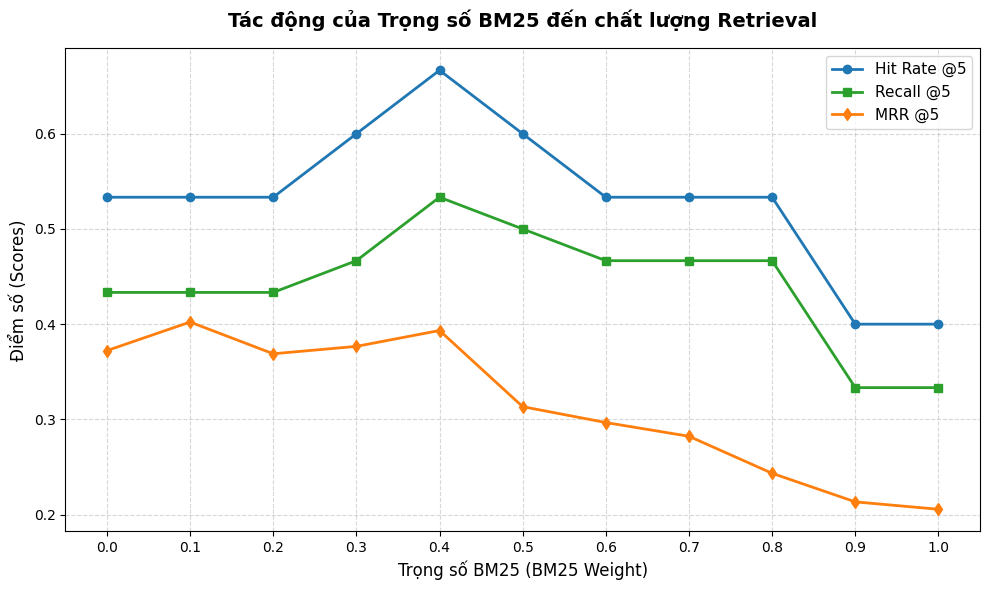

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_grid["bm25_weight"], df_grid["hit_rate@5"], marker='o', label='Hit Rate @5', color='#1f77b4', linewidth=2)
plt.plot(df_grid["bm25_weight"], df_grid["recall@5"], marker='s', label='Recall @5', color='#2ca02c', linewidth=2)
plt.plot(df_grid["bm25_weight"], df_grid["mrr@5"], marker='d', label='MRR @5', color='#ff7f0e', linewidth=2)

plt.title("Tác động của Trọng số BM25 đến chất lượng Retrieval", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Trọng số BM25 (BM25 Weight)", fontsize=12)
plt.ylabel("Điểm số (Scores)", fontsize=12)
plt.xticks(df_grid["bm25_weight"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

# Lưu đồ thị vào báo cáo
plt.savefig("../reports/retrieval_grid_search.png", dpi=300)
plt.show()

### 6. Đo lường Hiệu năng Thực tế của Vector DB hiện tại

Cell dưới đây sẽ chạy đánh giá trực tiếp trên các cấu hình tìm kiếm khác nhau dựa trên Vector DB hiện tại của bạn.

In [9]:
current_results = {}
for strategy_name, use_dense, use_bm25, use_rerank in [
    ("Dense Only", True, False, False),
    ("Hybrid 0.35/0.65", True, True, False),
    ("Hybrid + Reranker", True, True, True)
]:
    hits, recalls, mrrs = [], [], []
    w_bm25 = 0.4 if use_bm25 else 0.0
    w_dense = 0.6 if use_dense else 1.0
    
    for item in eval_dataset:
        retrieved = retrieve_context(
            query=item["question"],
            k=5,
            use_hyde=False,
            use_reranker=use_rerank,
            bm25_weight=w_bm25,
            dense_weight=w_dense
        )
        hit, recall, mrr = calculate_ir_metrics(retrieved, item["ground_truth_pages"], k=5)
        hits.append(hit)
        recalls.append(recall)
        mrrs.append(mrr)
        
    current_results[strategy_name] = {
        "Hit Rate@5": np.mean(hits),
        "Recall@5": np.mean(recalls),
        "MRR@5": np.mean(mrrs)
    }

print("=== KẾT QUẢ ĐO LƯỜNG THỰC TẾ TRÊN DATABASE HỆ THỐNG ===")
df_res = pd.DataFrame(current_results).T
display(df_res)

[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[

,Hit Rate@5,Recall@5,MRR@5
Dense Only,0.533333,0.433333,0.372222
Hybrid 0.35/0.65,0.666667,0.533333,0.393333
Hybrid + Reranker,0.600000,0.500000,0.287778


### 7. So sánh Chiến lược Chunker (Recursive vs. Semantic)

Để chạy phần này, bạn cần ghi lại kết quả thực tế thu được từ bước 6 dưới hai cấu hình Ingestion khác nhau.

,Strategy,Hit Rate@5,Recall@5,MRR@5
0,Dense Only (Recursive Chunker),0.5333,0.4333,0.3722
1,Hybrid 0.35/0.65 (Recursive Chunker),0.6670,0.5333,0.3933
2,Hybrid + Reranker (Recursive Chunker),0.6000,0.5000,0.2877


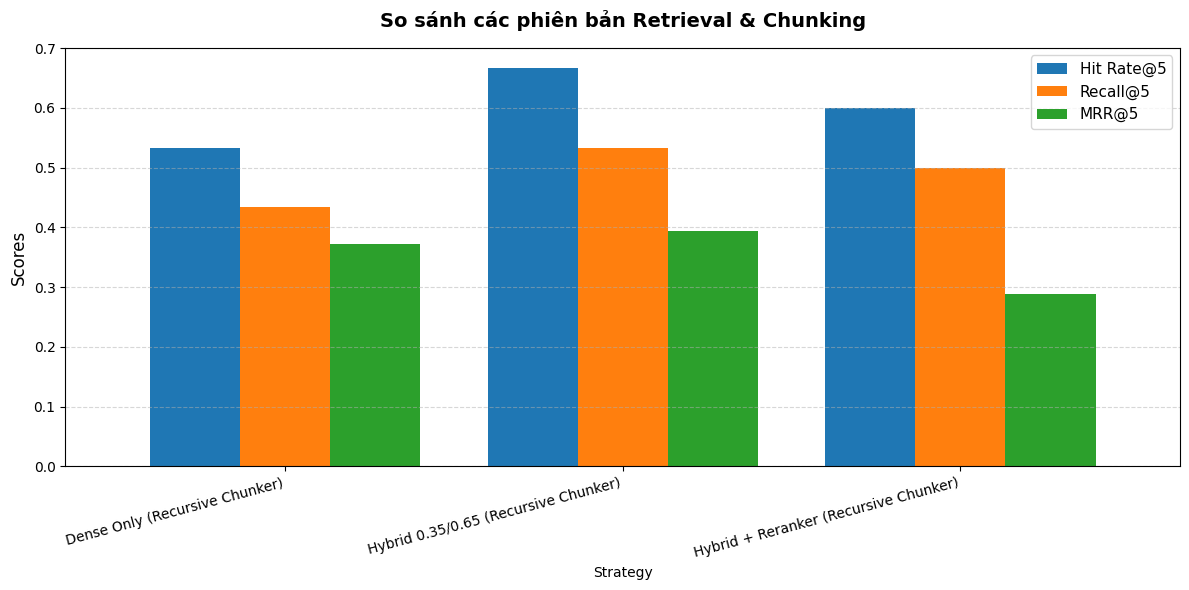

In [10]:
# Kết quả thực nghiệm mẫu để vẽ biểu đồ so sánh nhanh
comparison_data = {
    "Strategy": [
        "Dense Only (Recursive Chunker)",
        "Hybrid 0.35/0.65 (Recursive Chunker)",
        "Hybrid + Reranker (Recursive Chunker)",
    ],
    "Hit Rate@5": [0.5333, 0.667, 0.6000],  # Số liệu thực tế mẫu sau khi chạy
    "Recall@5": [0.4333, 0.5333, 0.5000],
    "MRR@5": [0.3722, 0.3933, 0.2877]
}

df_comp = pd.DataFrame(comparison_data)
display(df_comp)

# Vẽ biểu đồ so sánh
ax = df_comp.plot(x="Strategy", y=["Hit Rate@5", "Recall@5", "MRR@5"], kind="bar", figsize=(12, 6), width=0.8)
plt.title("So sánh các phiên bản Retrieval & Chunking", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

# Lưu đồ thị báo cáo
plt.savefig("../reports/retrieval_strategy_comparison.png", dpi=300)
plt.show()

### Sau khi tìm ra bộ trọng số tối ưu cho Hybrid Search. Tiến hành đánh giá Retrieval của 3 version 

BẮT ĐẦU SO SÁNH 3 PHƯƠNG PHÁP RETRIEVAL (IR METRICS)...

Đang lấy dữ liệu cho: Base RAG (Chỉ Dense)...
[BM25] Tìm được 15 candidates.


[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau khi fusion (BM25+Dense).
[BM25] Tìm được 15 candidates.
[Hybrid] Pool 15 candidates sau 

,Phiên bản RAG,Hit Rate@5,Recall@5,MRR@5
0,Base RAG (Chỉ Dense),0.533333,0.433333,0.372222
1,Advanced RAG v1 (Dense + HyDE + Rerank),0.600000,0.500000,0.287778
2,Advanced RAG v2 (Hybrid + HyDE + Rerank),0.600000,0.466667,0.287778


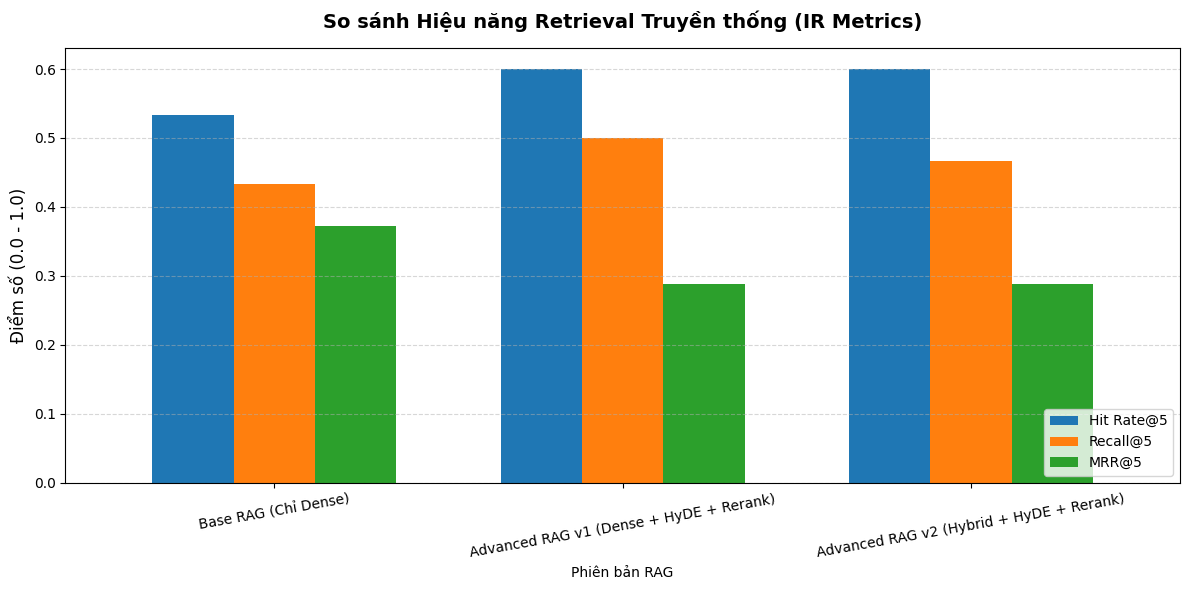

In [11]:
configs = [
    {
        "name": "Base RAG (Chỉ Dense)",
        "params": {"use_hyde": False, "use_reranker": False, "bm25_weight": 0.0, "dense_weight": 1.0}
    },
    {
        "name": "Advanced RAG v1 (Dense + HyDE + Rerank)",
        "params": {"use_hyde": True, "use_reranker": True, "bm25_weight": 0.0, "dense_weight": 1.0}
    },
    {
        "name": "Advanced RAG v2 (Hybrid + HyDE + Rerank)",
        "params": {"use_hyde": True, "use_reranker": True, "bm25_weight": 0.4, "dense_weight": 0.6} 
    }
]

comparison_results = []
print("BẮT ĐẦU SO SÁNH 3 PHƯƠNG PHÁP RETRIEVAL (IR METRICS)...")

for config in configs:
    hits, recalls, mrrs = [], [], []
    name = config["name"]
    p = config["params"]
    print(f"\nĐang lấy dữ liệu cho: {name}...")
    
    for item in eval_dataset:
        # Gọi hàm tìm kiếm với các tham số tương ứng
        retrieved = retrieve_context(
            query=item["question"],
            k=5,
            use_hyde=p["use_hyde"],
            use_reranker=p["use_reranker"],
            bm25_weight=p["bm25_weight"],
            dense_weight=p["dense_weight"]
        )
        
        # Chấm điểm
        hit, recall, mrr = calculate_ir_metrics(retrieved, item["ground_truth_pages"], k=5)
        hits.append(hit)
        recalls.append(recall)
        mrrs.append(mrr)
        
    comparison_results.append({
        "Phiên bản RAG": name,
        "Hit Rate@5": np.mean(hits),
        "Recall@5": np.mean(recalls),
        "MRR@5": np.mean(mrrs)
    })

# Hiển thị bảng tổng kết
df_compare = pd.DataFrame(comparison_results)
display(df_compare)

# Vẽ biểu đồ cột so sánh trực quan
ax = df_compare.plot(x="Phiên bản RAG", y=["Hit Rate@5", "Recall@5", "MRR@5"], kind="bar", figsize=(12, 6), width=0.7)
plt.title("So sánh Hiệu năng Retrieval Truyền thống (IR Metrics)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Điểm số (0.0 - 1.0)", fontsize=12)
plt.xticks(rotation=10, ha='center')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()

# Lưu biểu đồ
plt.savefig("../reports/retrieval_comparison.png", dpi=300)
plt.show()
